# Capítulo 2 · Generalización, sobreajuste y *data leakage*

Este notebook acompaña al capítulo 2 del libro y reproduce, en código ejecutable, tres ideas centrales:

1. Un modelo no debe aprender de memoria los datos de entrenamiento, sino **generalizar** a datos nuevos.
2. La **validación cruzada** permite estimar de forma más robusta el rendimiento cuando los datos son escasos.
3. El **data leakage** produce evaluaciones artificialmente optimistas cuando información del conjunto de validación o test se filtra durante el entrenamiento.

El notebook es completamente reproducible: todos los experimentos usan semillas aleatorias fijas.

In [1]:
# Imports básicos
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold, cross_val_score
from sklearn.datasets import load_breast_cancer
from sklearn.feature_selection import SelectKBest, f_classif

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)

NumPy: 2.3.5
Pandas: 2.2.3


## 1. Sobreajuste con regresión polinomial

Generamos datos sintéticos a partir de una función suave,

$$
y = \sin(2\pi x) + \varepsilon,
$$

con ruido gaussiano. Después ajustamos polinomios de distinta complejidad. El objetivo es comparar el error de entrenamiento con el error de test.

In [2]:
# Datos sintéticos
n_train = 20
n_test = 400
noise = 0.18

X_train = rng.uniform(0, 1, size=(n_train, 1))
y_train = np.sin(2 * np.pi * X_train[:, 0]) + rng.normal(0, noise, size=n_train)

X_test = np.linspace(0, 1, n_test).reshape(-1, 1)
y_true = np.sin(2 * np.pi * X_test[:, 0])
y_test = y_true + rng.normal(0, noise, size=n_test)

X_plot = np.linspace(0, 1, 500).reshape(-1, 1)
y_plot_true = np.sin(2 * np.pi * X_plot[:, 0])

In [3]:
degrees = [1, 3, 15]
rows = []
predictions = {}

for degree in degrees:
    model = Pipeline([
        ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
        ("lin", LinearRegression())
    ])
    model.fit(X_train, y_train)

    yhat_train = model.predict(X_train)
    yhat_test = model.predict(X_test)
    yhat_plot = model.predict(X_plot)

    rows.append({
        "grado": degree,
        "MSE entrenamiento": mean_squared_error(y_train, yhat_train),
        "MSE test": mean_squared_error(y_test, yhat_test),
    })
    predictions[degree] = yhat_plot

pd.DataFrame(rows).set_index("grado")

,MSE entrenamiento,MSE test
grado,,
1,0.206566,0.221961
3,0.020349,0.048450
15,0.002298,219962.202065


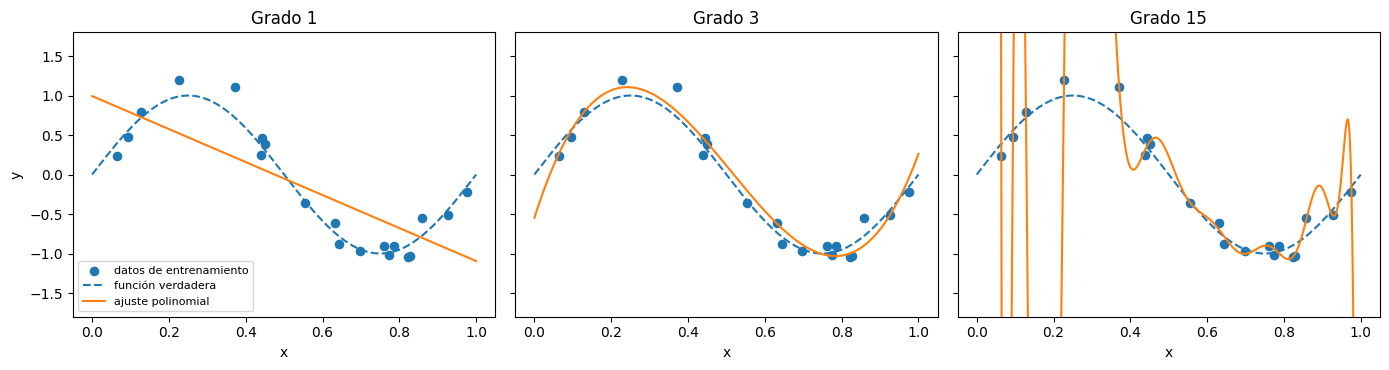

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8), sharey=True)

for ax, degree in zip(axes, degrees):
    ax.scatter(X_train[:, 0], y_train, s=35, label="datos de entrenamiento")
    ax.plot(X_plot[:, 0], y_plot_true, linestyle="--", label="función verdadera")
    ax.plot(X_plot[:, 0], predictions[degree], label="ajuste polinomial")
    ax.set_title(f"Grado {degree}")
    ax.set_xlabel("x")
    ax.set_ylim(-1.8, 1.8)

axes[0].set_ylabel("y")
axes[0].legend(loc="lower left", fontsize=8)
plt.tight_layout()
plt.show()

El polinomio de grado 1 subajusta: es demasiado rígido para capturar la curvatura real. El de grado 3 captura bien la estructura de los datos. El de grado 15 puede reducir mucho el error de entrenamiento, pero introduce oscilaciones que deterioran la generalización.

## 2. Complejidad del modelo y error de validación

Ahora repetimos el ajuste para muchos grados polinomiales y estimamos el error de generalización con validación cruzada. Para evitar problemas numéricos al trabajar con polinomios de grado alto, usamos una regularización Ridge muy suave dentro del `Pipeline`.

In [5]:
from sklearn.linear_model import Ridge

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
all_degrees = np.arange(1, 21)
cv_rmse_mean = []
cv_rmse_std = []
train_rmse = []

for degree in all_degrees:
    model = Pipeline([
        ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=1e-6))
    ])

    scores = cross_val_score(
        model, X_train, y_train,
        cv=cv,
        scoring="neg_root_mean_squared_error"
    )
    cv_rmse_mean.append(-scores.mean())
    cv_rmse_std.append(scores.std())

    model.fit(X_train, y_train)
    train_rmse.append(mean_squared_error(y_train, model.predict(X_train)) ** 0.5)

best_degree = all_degrees[np.argmin(cv_rmse_mean)]
print(f"Grado seleccionado por CV: {best_degree}")

Grado seleccionado por CV: 5


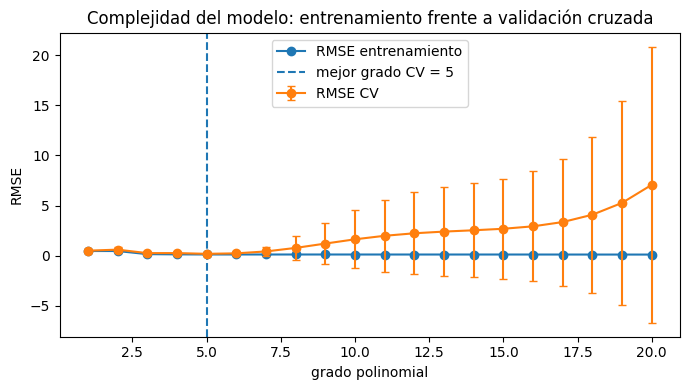

In [6]:
plt.figure(figsize=(7, 4))
plt.plot(all_degrees, train_rmse, marker="o", label="RMSE entrenamiento")
plt.errorbar(all_degrees, cv_rmse_mean, yerr=cv_rmse_std, marker="o", capsize=3, label="RMSE CV")
plt.axvline(best_degree, linestyle="--", label=f"mejor grado CV = {best_degree}")
plt.xlabel("grado polinomial")
plt.ylabel("RMSE")
plt.title("Complejidad del modelo: entrenamiento frente a validación cruzada")
plt.legend()
plt.tight_layout()
plt.show()

La curva de entrenamiento suele bajar al aumentar la complejidad, porque el modelo tiene más libertad para ajustarse a los datos. La curva de validación cruzada, en cambio, suele presentar un mínimo intermedio: primero mejora al reducir el sesgo, pero después empeora cuando la varianza domina.

## 3. Validación cruzada correcta con `Pipeline`

En problemas reales, el preprocesado debe formar parte del objeto que se valida. Aquí usamos el conjunto `breast_cancer` de scikit-learn para ilustrar una clasificación binaria con escalado y regresión logística.

In [7]:
data = load_breast_cancer()
X = data.data
y = data.target

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
auc_scores = cross_val_score(pipe, X, y, cv=cv, scoring="roc_auc")
acc_scores = cross_val_score(pipe, X, y, cv=cv, scoring="accuracy")

print(f"AUC-ROC:  {auc_scores.mean():.3f} ± {auc_scores.std():.3f}")
print(f"Accuracy: {acc_scores.mean():.3f} ± {acc_scores.std():.3f}")

AUC-ROC:  0.995 ± 0.005
Accuracy: 0.974 ± 0.017


La línea importante es conceptual: `StandardScaler` está dentro del `Pipeline`. Por tanto, en cada fold de la validación cruzada, la media y la desviación típica se calculan solo con el subconjunto de entrenamiento de ese fold, no con el fold de validación.

## 4. Implementación manual de k-fold CV

Para entender qué hace internamente `cross_val_score`, implementamos una versión mínima de validación cruzada. La función recibe un modelo compatible con scikit-learn, genera los pliegues y devuelve los scores.

In [8]:
from sklearn.base import clone
from sklearn.metrics import roc_auc_score


def cv_score_manual(model, X, y, k=5, random_state=42):
    '''Validación cruzada estratificada sencilla para AUC-ROC.'''
    cv = StratifiedKFold(n_splits=k, shuffle=True, random_state=random_state)
    scores = []

    for train_idx, val_idx in cv.split(X, y):
        X_tr, X_val = X[train_idx], X[val_idx]
        y_tr, y_val = y[train_idx], y[val_idx]

        model_fold = clone(model)
        model_fold.fit(X_tr, y_tr)

        # Para AUC necesitamos una puntuación continua, no solo la clase final.
        y_score = model_fold.predict_proba(X_val)[:, 1]
        scores.append(roc_auc_score(y_val, y_score))

    return np.array(scores)

manual_scores = cv_score_manual(pipe, X, y, k=5, random_state=RANDOM_STATE)
sklearn_scores = cross_val_score(pipe, X, y, cv=cv, scoring="roc_auc")

print("Manual:       ", np.round(manual_scores, 4))
print("scikit-learn: ", np.round(sklearn_scores, 4))
print("Diferencia máxima:", np.max(np.abs(manual_scores - sklearn_scores)))

Manual:        [0.9951 0.9977 0.9851 1.     0.9987]
scikit-learn:  [0.9951 0.9977 0.9851 1.     0.9987]
Diferencia máxima: 0.0


## 5. Experimento reproducible de *data leakage*

El caso más peligroso no siempre es el escalado. Un ejemplo mucho más dramático aparece cuando se hace **selección de variables usando todos los datos antes de la validación cruzada**. En el siguiente experimento, las etiquetas son aleatorias: no hay ninguna señal real que aprender. Un procedimiento honesto debería obtener AUC ≈ 0.5.

In [9]:
# Dataset sin señal real: X e y son independientes
n_samples = 140
n_features = 5000

X_noise = rng.normal(size=(n_samples, n_features))
y_noise = rng.integers(0, 2, size=n_samples)

cv_noise = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# MAL: selección de variables antes de CV. El selector ve todas las etiquetas,
# incluidas las que luego estarán en los folds de validación.
selector_bad = SelectKBest(score_func=f_classif, k=25)
X_selected_bad = selector_bad.fit_transform(X_noise, y_noise)

clf = LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)
scores_bad = cross_val_score(clf, X_selected_bad, y_noise, cv=cv_noise, scoring="roc_auc")

# BIEN: selección de variables dentro del Pipeline.
# En cada fold, SelectKBest se ajusta solo con el train-fold.
pipe_good = Pipeline([
    ("select", SelectKBest(score_func=f_classif, k=25)),
    ("clf", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE))
])
scores_good = cross_val_score(pipe_good, X_noise, y_noise, cv=cv_noise, scoring="roc_auc")

leakage_results = pd.DataFrame({
    "procedimiento": ["MAL: selección antes de CV", "BIEN: selección dentro del Pipeline"],
    "AUC medio": [scores_bad.mean(), scores_good.mean()],
    "AUC std": [scores_bad.std(), scores_good.std()],
})
leakage_results

,procedimiento,AUC medio,AUC std
0,MAL: selección antes de CV,0.942800,0.016888
1,BIEN: selección dentro del Pipeline,0.429948,0.057070


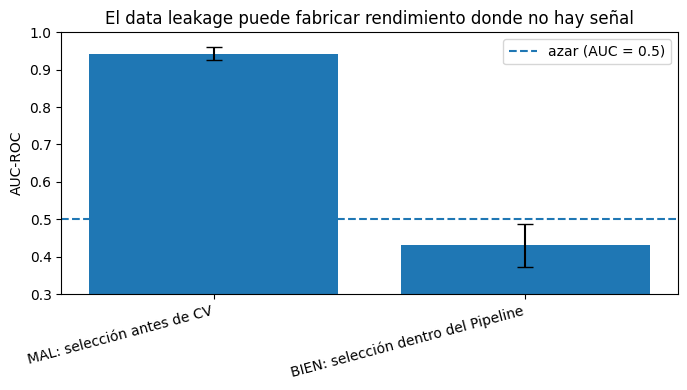

In [10]:
plt.figure(figsize=(7, 4))
plt.bar(leakage_results["procedimiento"], leakage_results["AUC medio"], yerr=leakage_results["AUC std"], capsize=6)
plt.axhline(0.5, linestyle="--", label="azar (AUC = 0.5)")
plt.ylim(0.3, 1.0)
plt.ylabel("AUC-ROC")
plt.title("El data leakage puede fabricar rendimiento donde no hay señal")
plt.xticks(rotation=15, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

El procedimiento incorrecto parece descubrir señal en datos donde no existe. La razón es que la selección de variables ha usado información de todas las etiquetas antes de crear los folds. El `Pipeline` evita este error porque la selección se reajusta desde cero dentro de cada fold usando solo los datos de entrenamiento de ese fold.

## 6. Regla práctica final

La regla operativa es sencilla:

> Todo paso que aprenda algo de los datos —escalado, imputación, reducción de dimensionalidad, selección de variables o ajuste del modelo— debe estar dentro del protocolo de validación.

En scikit-learn, eso casi siempre significa usar `Pipeline` y, cuando hay columnas de distinto tipo, `ColumnTransformer`.